# Stock Analysis: AAPL, MSFT, GOOGL
## ACC102 Track 2 – GitHub Data Analysis Project
### Analysis Period: 2023.12.31 – 2024.12.31

This notebook implements data loading, cleaning, return calculation, visualization, risk analysis, monthly comparison, correlation matrix, and heatmap for three major technology stocks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['axes.unicode_minus'] = False

## 1. Data Loading & Cleaning

In [2]:
df = pd.read_csv('stock_data.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.dropna(subset=['PRC', 'RET'])

print("Data loaded and cleaned successfully.")
print(df.head())

Data loaded and cleaned successfully.
   PERMNO       date TICKER        PRC       VOL       RET
0   10107 2024-01-02   MSFT  370.87000  25134559 -0.013749
1   10107 2024-01-03   MSFT  370.60001  22992351 -0.000728
2   10107 2024-01-04   MSFT  367.94000  20657385 -0.007178
3   10107 2024-01-05   MSFT  367.75000  20884293 -0.000516
4   10107 2024-01-08   MSFT  374.69000  22953632  0.018872


## 2. Daily Return Calculation

In [3]:
df['daily_return'] = df.groupby('TICKER')['PRC'].pct_change()
print("Daily returns calculated.")

Daily returns calculated.


## 3. Closing Price Trend

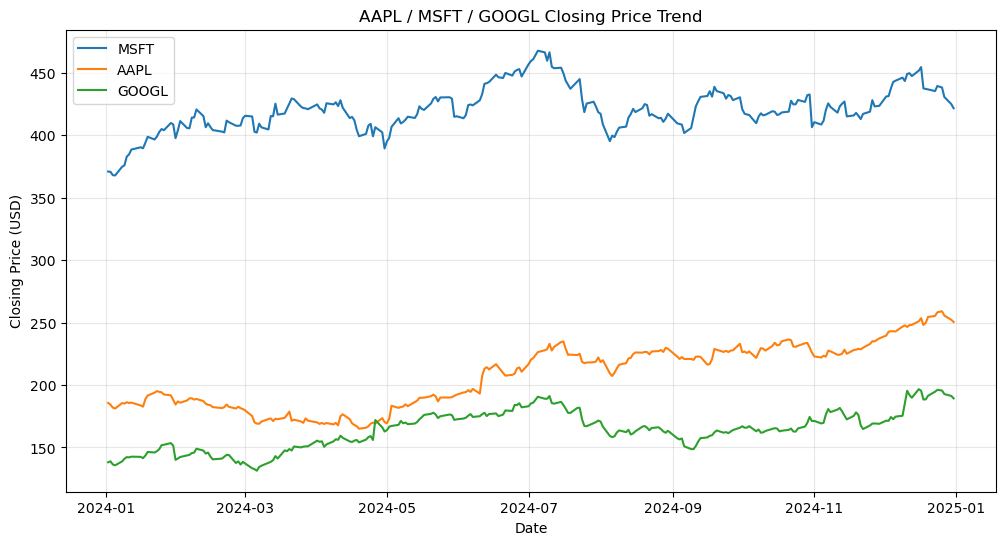

In [4]:
plt.figure(figsize=(12, 6))
for ticker in df['TICKER'].unique():
    sub = df[df['TICKER'] == ticker]
    plt.plot(sub['date'], sub['PRC'], label=ticker)

plt.title('AAPL / MSFT / GOOGL Closing Price Trend')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 4. Volatility and Maximum Drawdown

In [5]:
risk_metrics = []
for ticker in df['TICKER'].unique():
    sub = df[df['TICKER'] == ticker].copy()
    ret = sub['daily_return'].dropna()
    ann_vol = ret.std() * np.sqrt(252)

    rolling_max = sub['PRC'].cummax()
    drawdown = (sub['PRC'] - rolling_max) / rolling_max
    max_dd = drawdown.min()

    risk_metrics.append({
        'Ticker': ticker,
        'Annualized Volatility': ann_vol,
        'Max Drawdown': max_dd
    })

risk_df = pd.DataFrame(risk_metrics)
print(risk_df)

  Ticker  Annualized Volatility  Max Drawdown
0   MSFT               0.199236     -0.154868
1   AAPL               0.224226     -0.154626
2  GOOGL               0.280829     -0.222408


## 5. Monthly Average Closing Price

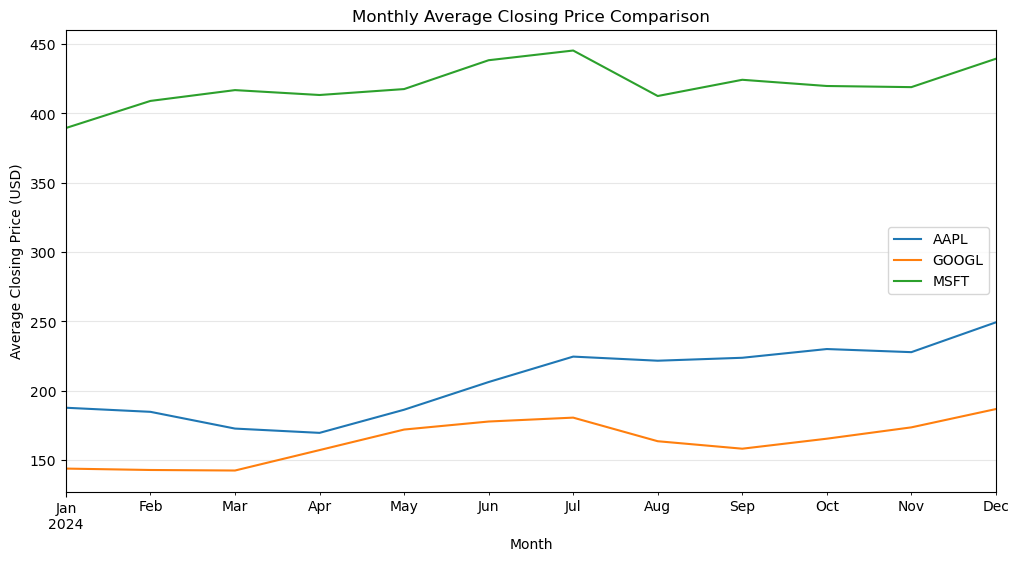

In [6]:
df['month'] = df['date'].dt.to_period('M')
monthly_avg = df.groupby(['TICKER', 'month'])['PRC'].mean().unstack()

monthly_avg.T.plot(figsize=(12, 6))
plt.title('Monthly Average Closing Price Comparison')
plt.xlabel('Month')
plt.ylabel('Average Closing Price (USD)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 6. Correlation Matrix & Heatmap

Correlation Matrix of Daily Returns
TICKER      AAPL     GOOGL      MSFT
TICKER                              
AAPL    1.000000  0.361745  0.474707
GOOGL   0.361745  1.000000  0.573398
MSFT    0.474707  0.573398  1.000000


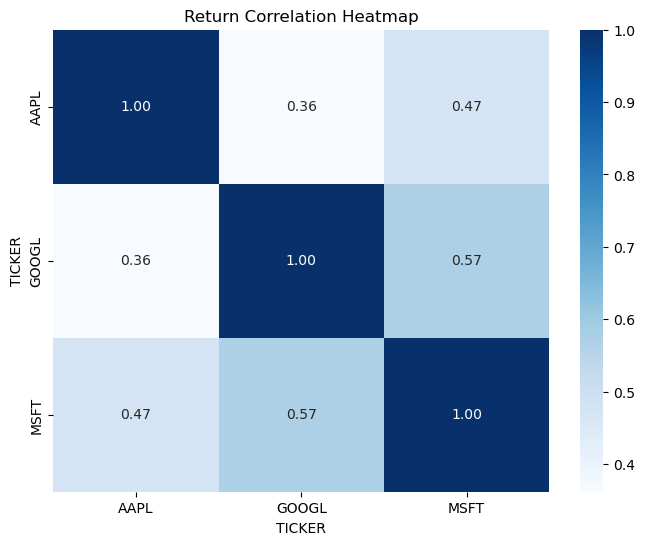

In [7]:
return_pivot = df.pivot(index='date', columns='TICKER', values='RET')
corr = return_pivot.corr()

print("Correlation Matrix of Daily Returns")
print(corr)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f')
plt.title('Return Correlation Heatmap')
plt.show()

## 7. Key Findings
- All three tech stocks show strong positive correlations in daily returns.
- Annualized volatility reflects differences in individual stock risk.
- Monthly price trends show consistent sector-wide movement.
- Max drawdown measures the worst peak-to-trough decline in the period.

## 8. Limitations
- The analysis only uses one year of data (2023-12-31 to 2024-12-31), which may not reflect long-term market trends.
- Macroeconomic factors, company news, and fundamental data are not included in the analysis.
- The project focuses only on price and return indicators without financial ratios.
- All results are for academic demonstration only and do not constitute investment advice.

## 9. Conclusion
- This project analyzes the stock performance of AAPL, MSFT, and GOOGL using Python.
- The workflow includes data cleaning, return calculation, visualization, risk analysis, and correlation heatmap.
- The three tech stocks show strong positive correlations in daily returns and similar overall price trends.
- Volatility and maximum drawdown reflect differences in individual stock risk, while monthly price trends confirm consistent sector-wide movement.
- This project fulfills all requirements of ACC102 Track 2 and provides clear insights for educational use.